In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import skew
!pip install catboost
from catboost import CatBoostClassifier

## 1. Load data + feature engineering

In [ ]:
df = pd.read_csv('creditcard.csv.gz')  # pandas reads gzip directly, no extraction needed
df.info()

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [5]:
df['Time'].value_counts()

Time
163152.0    36
64947.0     26
68780.0     25
3767.0      21
3770.0      20
            ..
127750.0     1
62260.0      1
62259.0      1
127753.0     1
172792.0     1
Name: count, Length: 124592, dtype: int64

In [6]:
df['Hour_Of_Day'] = (df['Time'] // 3600) % 24
df['Hour_Of_Day'].value_counts()

Hour_Of_Day
21.0    17703
18.0    17039
11.0    16856
20.0    16756
10.0    16598
14.0    16570
15.0    16461
16.0    16453
17.0    16166
9.0     15838
19.0    15649
22.0    15441
12.0    15420
13.0    15365
23.0    10938
8.0     10276
0.0      7695
7.0      7243
1.0      4220
6.0      4101
3.0      3492
2.0      3328
5.0      2990
4.0      2209
Name: count, dtype: int64

In [7]:
df = df.drop(columns=['Time'])

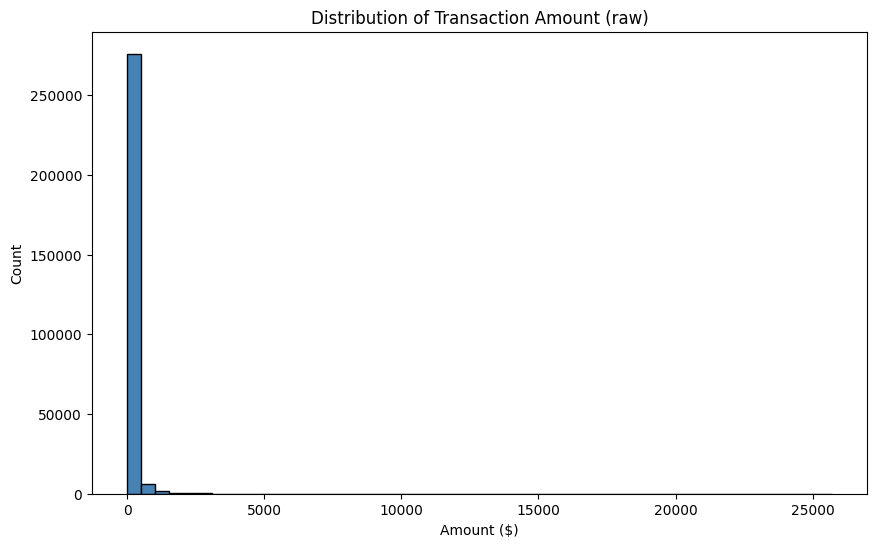

=== Amount: raw ===
Skewness (raw): 16.978
Zero-amount rows: 1825


In [8]:
# Check whether 'Amount' actually needs a log transform


plt.figure(figsize=(10, 6))
plt.hist(df['Amount'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Transaction Amount (raw)')
plt.xlabel('Amount ($)')
plt.ylabel('Count')
plt.savefig('amount_raw_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Amount: raw ===")

print(f"Skewness (raw): {skew(df['Amount']):.3f}")
print(f"Zero-amount rows: {(df['Amount'] == 0).sum()}")

Skewness (raw): 16.978
Skewness (log1p): 0.163


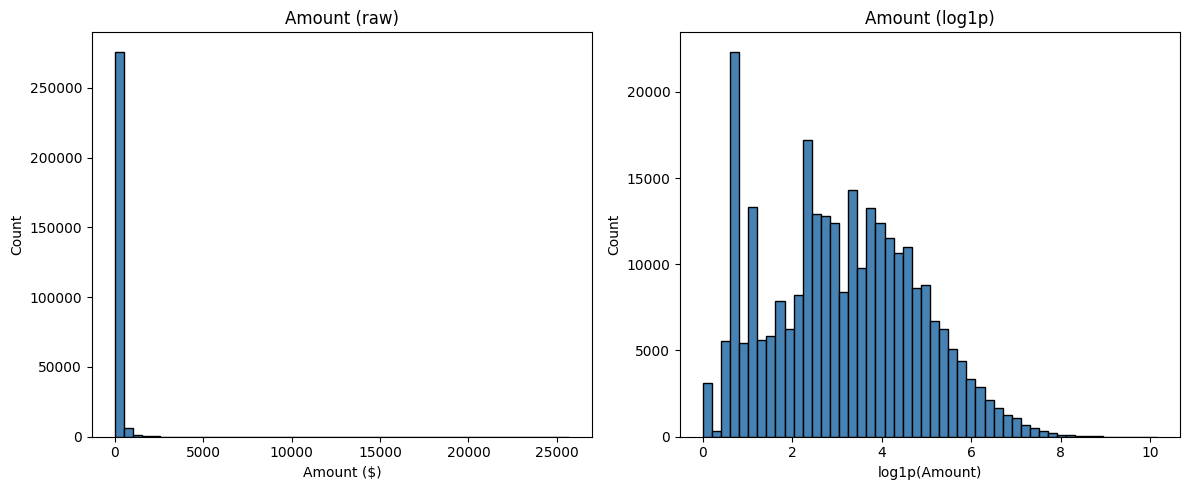

Saved distribution comparison to amount_distribution.png


In [9]:

logged_amount = np.log1p(df['Amount'])
print(f"Skewness (raw): {skew(df['Amount']):.3f}")
print(f"Skewness (log1p): {skew(logged_amount):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df['Amount'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Amount (raw)')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count')
axes[1].hist(logged_amount, bins=50, color='steelblue', edgecolor='black')
axes[1].set_title('Amount (log1p)')
axes[1].set_xlabel('log1p(Amount)')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150)
plt.show()
print("Saved distribution comparison to amount_distribution.png")



In [10]:
df['Amount'] = np.log1p(df['Amount'])

In [11]:
print(f"Skewness (logged): {skew(df['Amount']):.3f}")

Skewness (logged): 0.163


In [12]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

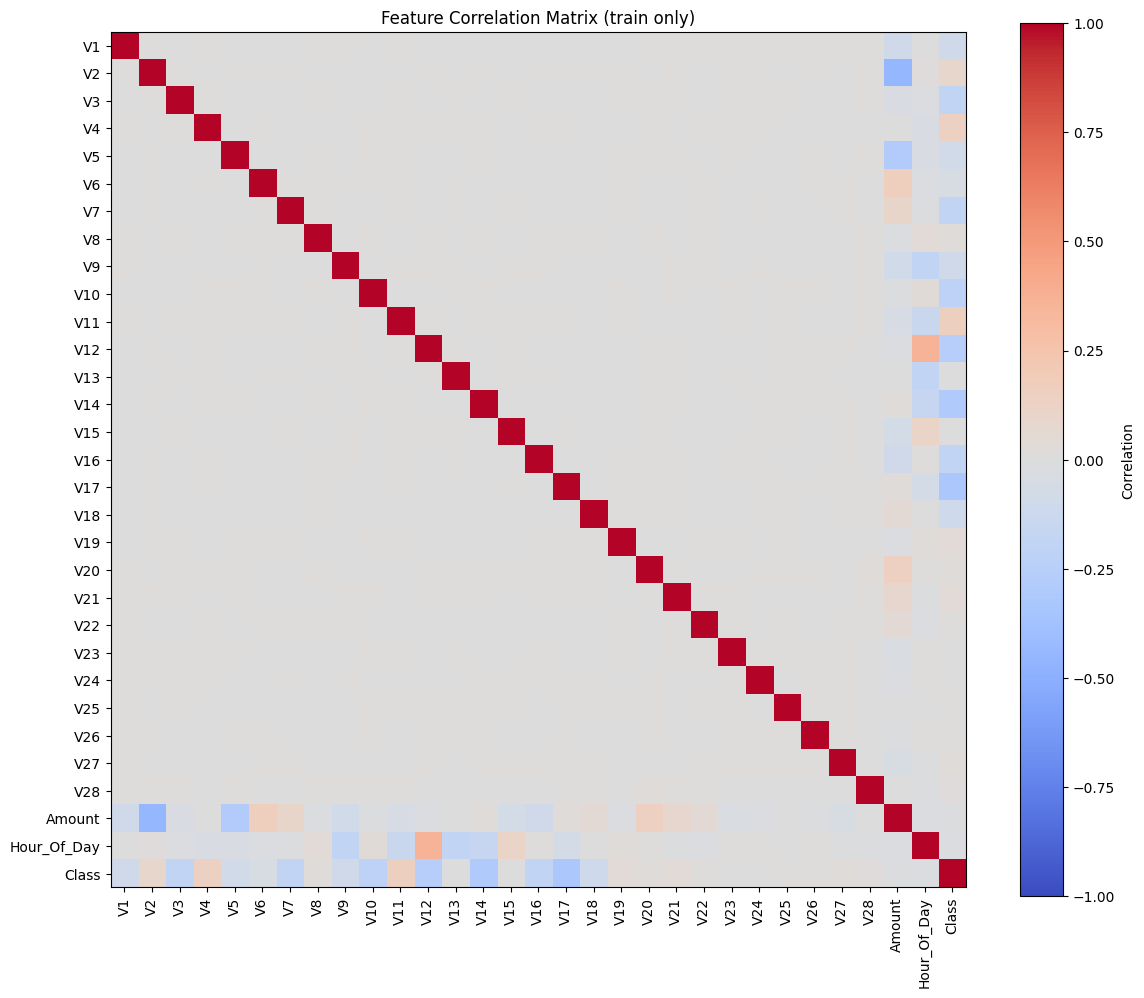

Class          1.000000
V11            0.153709
V4             0.135014
V2             0.090586
V21            0.035588
V19            0.032380
V8             0.020552
V20            0.019385
V27            0.016034
V28            0.009810
V26            0.004119
V22            0.002926
V25            0.001618
V23           -0.004169
V15           -0.005705
V13           -0.005861
V24           -0.007483
Amount        -0.008141
Hour_Of_Day   -0.016952
V6            -0.043334
V5            -0.093578
V9            -0.098247
V1            -0.100041
V18           -0.108732
V7            -0.186184
V16           -0.193826
V3            -0.194135
V10           -0.217894
V12           -0.259989
V14           -0.301054
V17           -0.321937
Name: Class, dtype: float64


In [13]:
train_full = X_train.copy()
train_full['Class'] = y_train
corr_matrix = train_full.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Feature Correlation Matrix (train only)')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

correlations_train = corr_matrix['Class'].sort_values(ascending=False)
print(correlations_train)

In [14]:
X_train['V14_V17_Interaction'] = X_train['V14'] * X_train['V17']
X_test['V14_V17_Interaction'] = X_test['V14'] * X_test['V17']

train_full = X_train.copy()
train_full['Class'] = y_train
correlations_train = train_full.corr()['Class'].sort_values(ascending=False)
print(correlations_train)

Class                  1.000000
V14_V17_Interaction    0.539683
V11                    0.153709
V4                     0.135014
V2                     0.090586
V21                    0.035588
V19                    0.032380
V8                     0.020552
V20                    0.019385
V27                    0.016034
V28                    0.009810
V26                    0.004119
V22                    0.002926
V25                    0.001618
V23                   -0.004169
V15                   -0.005705
V13                   -0.005861
V24                   -0.007483
Amount                -0.008141
Hour_Of_Day           -0.016952
V6                    -0.043334
V5                    -0.093578
V9                    -0.098247
V1                    -0.100041
V18                   -0.108732
V7                    -0.186184
V16                   -0.193826
V3                    -0.194135
V10                   -0.217894
V12                   -0.259989
V14                   -0.301054
V17     

In [15]:
WEAK_CORR_THRESHOLD = 0.008
corr_no_target = correlations_train.drop('Class')
weak_signal_series = corr_no_target[corr_no_target.abs() < WEAK_CORR_THRESHOLD].index.tolist()
print(f"\nDropping {len(weak_signal_series)} weak-correlation columns (|corr| < {WEAK_CORR_THRESHOLD}): {weak_signal_series}")

X_train = X_train.drop(weak_signal_series, axis=1)
X_test = X_test.drop(weak_signal_series, axis=1)


Dropping 7 weak-correlation columns (|corr| < 0.008): ['V26', 'V22', 'V25', 'V23', 'V15', 'V13', 'V24']


In [16]:
X_train.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V27', 'V28',
       'Amount', 'Hour_Of_Day', 'V14_V17_Interaction'],
      dtype='object')

## 2. Model selection (with vs. without SMOTE)

In [17]:
print("=" * 70)
print("STEP 1: MODEL SELECTION")
print("=" * 70)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_features='log2', n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=50, max_depth=6, n_jobs=-1, random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=50, n_jobs=-1, random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=50, random_state=42, verbose=0),
}

sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

selection_results = []
for use_smote, train_X, train_y in [
    (False, X_train, y_train),
    (True, X_train_balanced, y_train_balanced),
]:
    for name, model in models.items():
        model.fit(train_X, train_y)
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

        selection_results.append({
            "Model": name,
            "SMOTE": use_smote,
            "PR-AUC": round(average_precision_score(y_test, y_prob), 4),
            "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
            "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
            "F1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        })

selection_df = pd.DataFrame(selection_results).sort_values("PR-AUC", ascending=False)
print(selection_df.to_string(index=False))

champion_row = selection_df.iloc[0]
CHAMPION_NAME = champion_row["Model"]
CHAMPION_USES_SMOTE = bool(champion_row["SMOTE"])

print(f"\nCHAMPION: {CHAMPION_NAME} (SMOTE={CHAMPION_USES_SMOTE}), PR-AUC={champion_row['PR-AUC']}")

STEP 1: MODEL SELECTION
              Model  SMOTE  PR-AUC  ROC-AUC  Precision  Recall     F1
           CatBoost  False  0.8769   0.9764     0.9294  0.8061 0.8634
      Random Forest   True  0.8697   0.9653     0.8542  0.8367 0.8454
      Random Forest  False  0.8689   0.9533     0.9630  0.7959 0.8715
            XGBoost   True  0.8524   0.9773     0.5244  0.8776 0.6565
           CatBoost   True  0.8431   0.9793     0.4570  0.8673 0.5986
            XGBoost  False  0.7897   0.9393     0.8261  0.7755 0.8000
Logistic Regression  False  0.7752   0.9525     0.7766  0.7449 0.7604
           LightGBM   True  0.7400   0.9796     0.2730  0.9082 0.4198
Logistic Regression   True  0.7124   0.9700     0.0498  0.9184 0.0944
           LightGBM  False  0.1898   0.5792     0.3086  0.5102 0.3846

CHAMPION: CatBoost (SMOTE=False), PR-AUC=0.8769


## 3. Hyperparameter tuning for the champion

In [18]:

print("\n" + "="*70)
print("STEP 2: HYPERPARAMETER TUNING")
print("="*70)

base_estimator = clone(models[CHAMPION_NAME])

# Avoid nested parallelism: reset any inner threading param to 1 so
# GridSearchCV's own n_jobs=-1 is the only level of parallelism.
if "n_jobs" in base_estimator.get_params():
    base_estimator.set_params(n_jobs=1)
if "thread_count" in base_estimator.get_params():
    base_estimator.set_params(thread_count=1)

# 2. Define parameter grids for ALL possible champion models
param_grids = {
    "Logistic Regression": {
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__class_weight": [None, "balanced"],
    },
    "Random Forest": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [None, 10, 20, 30, 50],
        "clf__min_samples_leaf": [1, 5, 10, 20, 50],
        "clf__max_features": ["log2", "sqrt"],
        "clf__class_weight": ["balanced_subsample", "balanced", None],
    },
    "XGBoost": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [3, 6, 10],
        "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "clf__subsample": [0.8, 1.0],
    },
    "LightGBM": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [-1, 10, 20],
        "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "clf__num_leaves": [31, 50, 100],
    },
    "CatBoost": {
        "clf__iterations": [100, 200],
        "clf__depth": [4, 6, 8],
        "clf__learning_rate": [0.01, 0.05, 0.1],
    },
}

# 3. Select the correct grid for the winning model
param_grid = param_grids[CHAMPION_NAME]

# 4. Build the pipeline depending on whether SMOTE was needed
if CHAMPION_USES_SMOTE:
    tuning_pipeline = ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", base_estimator),
    ])
else:
    tuning_pipeline = ImbPipeline([("clf", base_estimator)])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=2,
)

print(f"Tuning {CHAMPION_NAME} (SMOTE={CHAMPION_USES_SMOTE})...")
grid_search.fit(X_train, y_train)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV PR-AUC: {grid_search.best_score_:.4f}")

tuned_model = grid_search.best_estimator_
test_probs = tuned_model.predict_proba(X_test)[:, 1]


STEP 2: HYPERPARAMETER TUNING
Tuning CatBoost (SMOTE=False)...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best params: {'clf__depth': 8, 'clf__iterations': 100, 'clf__learning_rate': 0.1}
Best CV PR-AUC: 0.8495


In [19]:
import numpy as np
from sklearn.metrics import average_precision_score, f1_score, fbeta_score

thresholds = np.arange(0.0, 1.05, 0.05)
best_f1, best_f1_t = -1, None
best_f2, best_f2_t = -1, None
for t in thresholds:
    pred = (test_probs >= t).astype(int)
    f1 = f1_score(y_test, pred, zero_division=0)
    f2 = fbeta_score(y_test, pred, beta=2, zero_division=0)
    if f1 > best_f1:
        best_f1, best_f1_t = f1, t
    if f2 > best_f2:
        best_f2, best_f2_t = f2, t

print(f"PR-AUC (Average Precision): {average_precision_score(y_test, test_probs):.4f}")
print(f"F1-max: {best_f1:.4f} at threshold {best_f1_t:.2f}")
print(f"F2-max: {best_f2:.4f} at threshold {best_f2_t:.2f}")

PR-AUC (Average Precision): 0.8748
F1-max: 0.8817 at threshold 0.25
F2-max: 0.8574 at threshold 0.15


In [20]:
print(X_train.shape)
print(sorted(X_train.columns.tolist()))

(227845, 24)
['Amount', 'Hour_Of_Day', 'V1', 'V10', 'V11', 'V12', 'V14', 'V14_V17_Interaction', 'V16', 'V17', 'V18', 'V19', 'V2', 'V20', 'V21', 'V27', 'V28', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9']


In [21]:
print(type(tuned_model).__name__)

Pipeline


## 4. Threshold sweep: find best F1 and F2 thresholds

In [22]:
print("\n" + "=" * 70)
print("STEP 3: THRESHOLD SWEEP")
print("=" * 70)

thresholds = np.arange(0.0, 1.05, 0.01)
sweep_results = []

print(f"{'thresh':>7} | {'precision':>9} | {'recall':>7} | {'f1':>6} | {'f2':>6}")
for t in thresholds:
    pred_t = (test_probs >= t).astype(int)
    p = precision_score(y_test, pred_t, zero_division=0)
    r = recall_score(y_test, pred_t, zero_division=0)
    f1 = f1_score(y_test, pred_t, zero_division=0)
    f2 = fbeta_score(y_test, pred_t, beta=2, zero_division=0)
    sweep_results.append({"threshold": t, "precision": p, "recall": r, "f1": f1, "f2": f2})
    print(f"{t:>7.2f} | {p:>9.3f} | {r:>7.3f} | {f1:>6.3f} | {f2:>6.3f}")

sweep_df = pd.DataFrame(sweep_results)

roc_auc = roc_auc_score(y_test, test_probs)
pr_auc = average_precision_score(y_test, test_probs)


STEP 3: THRESHOLD SWEEP
 thresh | precision |  recall |     f1 |     f2
   0.00 |     0.002 |   1.000 |  0.003 |  0.009
   0.01 |     0.425 |   0.898 |  0.577 |  0.735
   0.02 |     0.565 |   0.888 |  0.690 |  0.797
   0.03 |     0.667 |   0.878 |  0.758 |  0.825
   0.04 |     0.735 |   0.878 |  0.800 |  0.845
   0.05 |     0.759 |   0.867 |  0.810 |  0.843
   0.06 |     0.787 |   0.867 |  0.825 |  0.850
   0.07 |     0.817 |   0.867 |  0.842 |  0.857
   0.08 |     0.825 |   0.867 |  0.846 |  0.859
   0.09 |     0.848 |   0.857 |  0.853 |  0.855
   0.10 |     0.857 |   0.857 |  0.857 |  0.857
   0.11 |     0.857 |   0.857 |  0.857 |  0.857
   0.12 |     0.875 |   0.857 |  0.866 |  0.861
   0.13 |     0.894 |   0.857 |  0.875 |  0.864
   0.14 |     0.892 |   0.847 |  0.869 |  0.856
   0.15 |     0.902 |   0.847 |  0.874 |  0.857
   0.16 |     0.902 |   0.847 |  0.874 |  0.857
   0.17 |     0.901 |   0.837 |  0.868 |  0.849
   0.18 |     0.901 |   0.837 |  0.868 |  0.849
   0.19 |     0

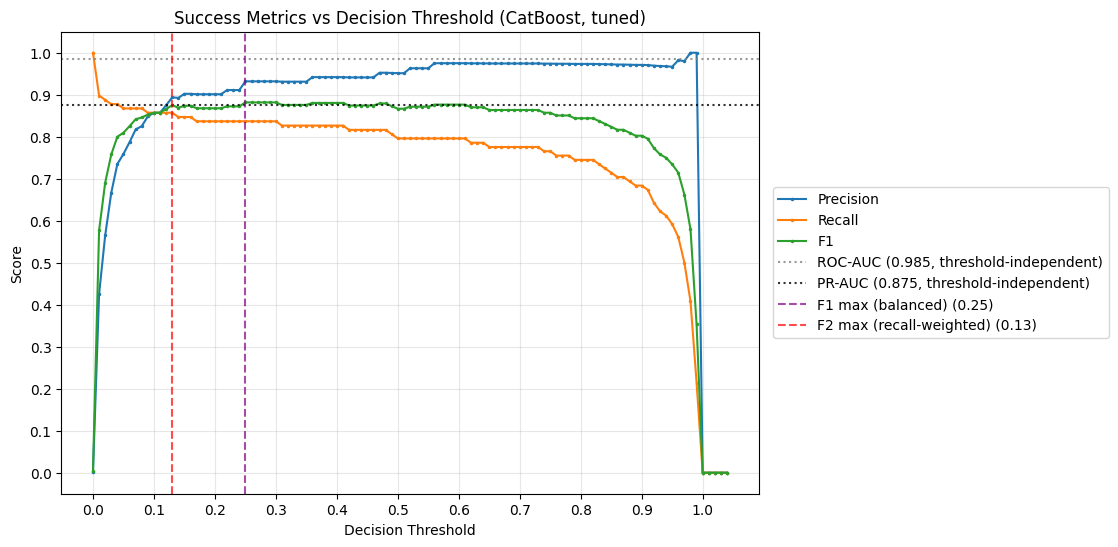

F1-max threshold (balanced): 0.25
F2-max threshold (recall-weighted): 0.13


In [23]:
plt.figure(figsize=(9, 6))
plt.plot(sweep_df['threshold'], sweep_df['precision'], marker='o', markersize=1.5, label='Precision')
plt.plot(sweep_df['threshold'], sweep_df['recall'], marker='o', markersize=1.5, label='Recall')
plt.plot(sweep_df['threshold'], sweep_df['f1'], marker='o', markersize=1.5, label='F1')
plt.axhline(roc_auc, color='gray', linestyle=':', alpha=0.8, label=f'ROC-AUC ({roc_auc:.3f}, threshold-independent)')
plt.axhline(pr_auc, color='black', linestyle=':', alpha=0.8, label=f'PR-AUC ({pr_auc:.3f}, threshold-independent)')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title(f'Success Metrics vs Decision Threshold ({CHAMPION_NAME}, tuned)')
plt.xticks(np.arange(0, 1.05, 0.1))
plt.yticks(np.arange(0, 1.05, 0.1))
plt.grid(True, alpha=0.3)

f1_best_idx = sweep_df['f1'].idxmax()
F1_BEST_THRESHOLD = round(sweep_df.loc[f1_best_idx, 'threshold'], 2)

f2_best_idx = sweep_df['f2'].idxmax()
F2_BEST_THRESHOLD = round(sweep_df.loc[f2_best_idx, 'threshold'], 2)

plt.axvline(F1_BEST_THRESHOLD, color='purple', linestyle='--', alpha=0.7,
            label=f'F1 max (balanced) ({F1_BEST_THRESHOLD})')
plt.axvline(F2_BEST_THRESHOLD, color='red', linestyle='--', alpha=0.7,
            label=f'F2 max (recall-weighted) ({F2_BEST_THRESHOLD})')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.savefig('threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"F1-max threshold (balanced): {F1_BEST_THRESHOLD}")
print(f"F2-max threshold (recall-weighted): {F2_BEST_THRESHOLD}")

## 5. Full evaluation at F1-max and F2-max thresholds


FULL EVALUATION — F1-max (balanced) threshold = 0.25

=== Classification Report (test, threshold=0.25) ===
              precision    recall  f1-score   support

       legit       1.00      1.00      1.00     56864
       fraud       0.93      0.84      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9854
PR-AUC (Average Precision): 0.8748
True Positives (fraud caught):    82
False Positives (false alarms):   6
False Negatives (fraud missed):   16
True Negatives (legit correct):   56858


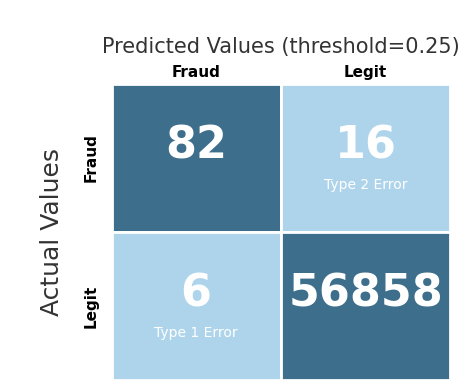

Saved confusion matrix visual to confusion_matrix_f1.png

FULL EVALUATION — F2-max (recall-weighted) threshold = 0.13

=== Classification Report (test, threshold=0.13) ===
              precision    recall  f1-score   support

       legit       1.00      1.00      1.00     56864
       fraud       0.89      0.86      0.88        98

    accuracy                           1.00     56962
   macro avg       0.95      0.93      0.94     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9854
PR-AUC (Average Precision): 0.8748
True Positives (fraud caught):    84
False Positives (false alarms):   10
False Negatives (fraud missed):   14
True Negatives (legit correct):   56854


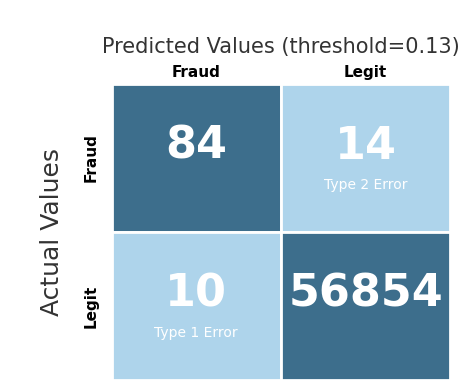

Saved confusion matrix visual to confusion_matrix_f2.png


In [24]:
def plot_confusion_matrix(y_true, y_pred, threshold, filename):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

    print(f"True Positives (fraud caught):    {tp}")
    print(f"False Positives (false alarms):   {fp}")
    print(f"False Negatives (fraud missed):   {fn}")
    print(f"True Negatives (legit correct):   {tn}")

    dark_blue = '#3d6e8c'
    light_blue = '#aed4eb'

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.invert_yaxis()
    ax.axis('off')

    cells = [
        (0, 0, tp, dark_blue, None),
        (1, 0, fn, light_blue, 'Type 2 Error'),
        (0, 1, fp, light_blue, 'Type 1 Error'),
        (1, 1, tn, dark_blue, None),
    ]

    for x, y_pos, value, color, error_label in cells:
        ax.add_patch(plt.Rectangle((x, y_pos), 1, 1, facecolor=color, edgecolor='white', linewidth=2))
        ax.text(x + 0.5, y_pos + 0.42, f'{value}', ha='center', va='center',
                fontsize=32, fontweight='bold', color='white')
        if error_label:
            ax.text(x + 0.5, y_pos + 0.68, error_label, ha='center', va='center',
                    fontsize=10, color='white')

    ax.text(1.0, -0.25, f'Predicted Values (threshold={threshold})', ha='center', va='center',
            fontsize=15, color='#333')
    ax.text(0.5, -0.08, 'Fraud', ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(1.5, -0.08, 'Legit', ha='center', va='center', fontsize=11, fontweight='bold')

    ax.text(-0.35, 1.0, 'Actual Values', ha='center', va='center', fontsize=18,
            color='#333', rotation=90)
    ax.text(-0.12, 0.5, 'Fraud', ha='center', va='center', fontsize=11, fontweight='bold', rotation=90)
    ax.text(-0.12, 1.5, 'Legit', ha='center', va='center', fontsize=11, fontweight='bold', rotation=90)

    ax.set_xlim(-0.6, 2)
    ax.set_ylim(2, -0.5)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved confusion matrix visual to {filename}")


def evaluate_at_threshold(threshold, label, cm_filename):
    print(f"\n{'=' * 60}")
    print(f"FULL EVALUATION — {label} threshold = {threshold}")
    print(f"{'=' * 60}")

    test_pred_at_threshold = (test_probs >= threshold).astype(int)

    print(f"\n=== Classification Report (test, threshold={threshold}) ===")
    print(classification_report(y_test, test_pred_at_threshold, target_names=['legit', 'fraud']))
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

    plot_confusion_matrix(y_test, test_pred_at_threshold, threshold, filename=cm_filename)


evaluate_at_threshold(F1_BEST_THRESHOLD, "F1-max (balanced)", "confusion_matrix_f1.png")
evaluate_at_threshold(F2_BEST_THRESHOLD, "F2-max (recall-weighted)", "confusion_matrix_f2.png")

## 6. Summary of Fraud Feature Importance

            Feature  Importance
                 V4   11.978562
                 V1    8.303308
                V14    5.982046
                V12    5.709169
                V20    5.521973
                V10    5.170112
                V11    4.809711
                 V5    4.792114
             Amount    4.764831
                V16    4.418386
                 V8    4.395656
                V19    3.869685
V14_V17_Interaction    3.684509
                V21    3.506320
        Hour_Of_Day    3.247223
                V27    3.141607
                 V9    2.887825
                 V2    2.842166
                 V7    2.665793
                V17    2.050168
                 V6    1.918344
                 V3    1.759567
                V28    1.499239
                V18    1.081687


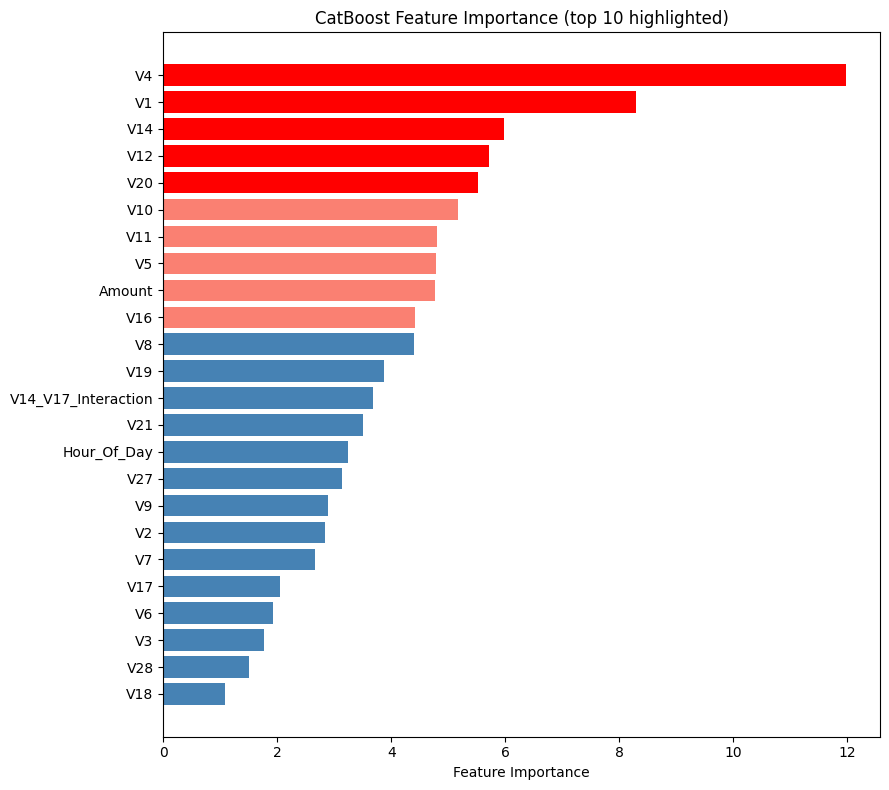

In [25]:

final_model = tuned_model.named_steps['clf']

importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importances.to_string(index=False))


TOP_Features = 10
TOP_Half = TOP_Features // 2

colors = ['red' if i < TOP_Half else 'salmon' if i < TOP_Features else 'steelblue' for i in range(len(importances))]



plt.figure(figsize=(9, 8))
plt.barh(importances['Feature'][::-1], importances['Importance'][::-1], color=colors[::-1])
plt.xlabel('Feature Importance')


plt.title(f'CatBoost Feature Importance (top {TOP_Features} highlighted)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
top_features = importances['Feature'].head(TOP_Features).tolist()

table_data = []

for feature in top_features:
    overall = df[feature]
    fraud = df.loc[df['Class'] == 1, feature]
    
    if feature == 'Amount':
        fraud = np.expm1(fraud)

    table_data.append({
        'Feature': feature,
        'Overall Range': f"{overall.min():.2f} to {overall.max():.2f}",
        'Fraud Average': round(fraud.mean(), 2)
    })

results_table = pd.DataFrame(table_data)
display(results_table)

,Feature,Overall Range,Fraud Average
0,V4,-5.68 to 16.88,4.54
1,V1,-56.41 to 2.45,-4.77
2,V14,-19.21 to 10.53,-6.97
3,V12,-18.68 to 7.85,-6.26
4,V20,-54.50 to 39.42,0.37
5,V10,-24.59 to 23.75,-5.68
6,V11,-4.80 to 12.02,3.80
7,V5,-113.74 to 34.80,-3.15
8,Amount,0.00 to 10.15,122.21
9,V16,-14.13 to 17.32,-4.14
